# UR5 – Cinemática Direta com Python + CoppeliaSim
### ENGA73 – Sistemas Robóticos | UFBA 2026.1



---
## 1. Imports e Parâmetros DH

Usa a convenção **DH Padrão** onde cada linha `i` descreve os parâmetros do link atual:  
`T = Rz(θ)·Tz(d)·Tx(a)·Rx(α)`

| Joint | a (m) | α | d (m) |
|---|---|---|---|
| 1 | 0 | +90° | 0.089159 |
| 2 | −0.425 | 0° | 0 |
| 3 | −0.39225 | 0° | 0 |
| 4 | 0 | +90° | 0.10915 |
| 5 | 0 | −90° | 0.09465 |
| 6 | 0 | 0° | 0.0823 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

# D6 = 0.0823
# Parâmetros DH – UR5
D1, D4, D5, D6 = 0.089159, 0.10915, 0.09465, 0.17591
A2, A3         = -0.425, -0.39225

# Tabela DH p
DH = [
    [ np.pi/2,    0,   D1],  # joint 1
    [ 0,         A2,    0],  # joint 2
    [ 0,         A3,    0],  # joint 3
    [ np.pi/2,    0,   D4],  # joint 4
    [-np.pi/2,    0,   D5],  # joint 5
    [ 0,          0,   D6],  # joint 6
]

print('Parâmetros DH:')
print(f"  {'i':<4} {'α (°)':>8} {'a (m)':>10} {'d (m)':>10}")
print('  ' + '-'*36)
for i,(alpha,a,d) in enumerate(DH):
    print(f'  {i+1:<4} {np.degrees(alpha):>8.1f} {a:>10.5f} {d:>10.5f}')


Parâmetros DH:
  i       α (°)      a (m)      d (m)
  ------------------------------------
  1        90.0    0.00000    0.08916
  2         0.0   -0.42500    0.00000
  3         0.0   -0.39225    0.00000
  4        90.0    0.00000    0.10915
  5       -90.0    0.00000    0.09465
  6         0.0    0.00000    0.17591


---
## 2. Funções de Cinemática Direta


In [3]:
def dh_transform(alpha, a, d, theta):
    """
    Transformação DH:
    T = Rz(θ) · Tz(d) · Tx(a) · Rx(α)
    """
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct,  -st*ca,  st*sa,  a*ct],
        [st,   ct*ca, -ct*sa,  a*st],
        [ 0,    sa,    ca,     d   ],
        [ 0,    0,     0,      1   ]
    ])

def fk(thetas_deg):
    """FK completa. Retorna T (4x4) e cadeia de frames."""
    thetas = np.radians(thetas_deg)
    T = np.eye(4)
    chain = [T.copy()]
    for (alpha,a,d), theta in zip(DH, thetas):
        T = T @ dh_transform(alpha, a, d, theta)
        chain.append(T.copy())
    return T, chain

def rotation_to_rpy(R):
    """Extrai roll-pitch-yaw (ZYX) em graus de R (3x3)."""
    sy = np.sqrt(R[0,0]**2 + R[1,0]**2)
    if sy > 1e-6:
        roll  = np.degrees(np.
        arctan2( R[2,1], R[2,2]))
        pitch = np.degrees(np.arctan2(-R[2,0], sy))
        yaw   = np.degrees(np.arctan2( R[1,0], R[0,0]))
    else:
        roll  = np.degrees(np.arctan2(-R[1,2], R[1,1]))
        pitch = np.degrees(np.arctan2(-R[2,0], sy))
        yaw   = 0.0
    return np.array([roll, pitch, yaw])

def euler_xyz_to_matrix(rpy_deg):
    """Euler intrínseco XYZ (CoppeliaSim) → matriz R (3x3)."""
    rx, ry, rz = np.radians(rpy_deg)
    Rx = np.array([[1,0,0],[0,np.cos(rx),-np.sin(rx)],[0,np.sin(rx),np.cos(rx)]])
    Ry = np.array([[np.cos(ry),0,np.sin(ry)],[0,1,0],[-np.sin(ry),0,np.cos(ry)]])
    Rz = np.array([[np.cos(rz),-np.sin(rz),0],[np.sin(rz),np.cos(rz),0],[0,0,1]])
    return Rx @ Ry @ Rz

def angular_error_deg(R_calc, R_gt):
    """Erro angular entre duas matrizes R — independente de convenção Euler."""
    R_err = R_calc.T @ R_gt
    cos_a = np.clip((np.trace(R_err) - 1) / 2, -1, 1)
    return np.degrees(np.arccos(cos_a))





---
## 3. Conexão com o CoppeliaSim
> ▶ Certifique-se que a simulação está em **Play** antes desta célula.


In [4]:
client = RemoteAPIClient()
sim    = client.getObject('sim')


---
## 4. Handles dos Objetos


In [5]:
joint_handles = []
for i in range(1, 7):
    h = sim.getObject(f'/UR5_joint{i}')
    print(f"  ✅ UR5_joint{i}: handle={h}")
    joint_handles.append(h)

base_handle = sim.getObject('/frame0')
ee_handle   = sim.getObject('/frame6')

print(f"\n  ✅ Base 'frame0' : handle={base_handle}")
print(f"  ✅ EE 'frame6'   : handle={ee_handle}")

  ✅ UR5_joint1: handle=32
  ✅ UR5_joint2: handle=35
  ✅ UR5_joint3: handle=38
  ✅ UR5_joint4: handle=41
  ✅ UR5_joint5: handle=44
  ✅ UR5_joint6: handle=46

  ✅ Base 'frame0' : handle=31
  ✅ EE 'frame6'   : handle=116


---
## 5. Funções de Controle e Leitura


In [6]:
def set_joint_positions(thetas_deg):
    """Envia posições alvo para as 6 juntas (graus)."""
    for handle, angle in zip(joint_handles, thetas_deg):
        sim.setJointTargetPosition(handle, np.radians(angle))

def read_joint_positions():
    """Lê ângulos atuais das 6 juntas em graus."""
    angles = []
    for handle in joint_handles:
        angles.append(np.degrees(sim.getJointPosition(handle)))
    return np.array(angles)

def read_ee_pose():
    """
    Lê posição e orientação do EE relativa à BASE.
    Usa base_handle como referência.
    """
    pos   = sim.getObjectPosition(ee_handle, base_handle)
    euler = sim.getObjectOrientation(ee_handle, base_handle)
    return np.array(pos), np.degrees(euler)

---
## 6. Offset de Junta e Orientação

O zero físico das juntas na cena ≠ zero do modelo DH (robô deitado vs. em pé).  
`JOINT_OFFSET = [0, -90, 0, -90, 0, 0]°` corrige essa diferença.  
`R_offset` corrige a rotação do frame do EE entre a cena e o modelo DH.


In [7]:
# Offset entre zero do CoppeliaSim (robô em pé) e zero do modelo DH (robô deitado)
JOINT_OFFSET = np.array([0, -90, 0, -90, 0, 0], dtype=float)

def fk_com_offset(thetas_deg):
    """FK aplicando o offset de referência da cena."""
    return fk(np.array(thetas_deg, dtype=float) + JOINT_OFFSET)

set_joint_positions([0,0,0,0,0,0])
time.sleep(1.5)

gt_pos_ref, gt_euler_ref = read_ee_pose()
T_ref, _ = fk_com_offset([0,0,0,0,0,0])

print(f'JOINT_OFFSET : {JOINT_OFFSET}')
print(f'\nPose zero — FK    : {np.round(T_ref[:3,3],4)}')
print(f'Pose zero — Simul.: {np.round(gt_pos_ref,4)}')
print(f'Erro inicial      : {np.linalg.norm(T_ref[:3,3]-gt_pos_ref)*1000:.2f} mm')


JOINT_OFFSET : [  0. -90.   0. -90.   0.   0.]

Pose zero — FK    : [-0.     -0.2851  1.0011]
Pose zero — Simul.: [-2.000e-04 -2.863e-01  1.001e+00]
Erro inicial      : 1.25 mm


---
## 7. Validação com 5 Poses

Para cada pose: envia ao simulador → lê ground truth → calcula FK → compara.


In [ ]:
test_poses = [
    [  0, -45,  90, -45,  30,   0],
    [ 60, -30,  25, -45,  65,  30],
    [-60, -30,  75, 150,  70, -30],
    [ 30, -25,  -45, -20,  45,  45],
    [ 90, -45,  60,  30, -60,  90],
]

results = []

print(f"{'='*58}")
print(f'  Validação FK ')
print(f"{'='*58}")

for i, pose in enumerate(test_poses):
    set_joint_positions(pose)
    time.sleep(1.5)

    gt_pos, gt_euler = read_ee_pose()

    T, _ = fk_com_offset(pose) 
    calc_pos = T[:3, 3]
    R_calc   = T[:3,:3] 
    R_gt     = euler_xyz_to_matrix(gt_euler)

    pos_err = np.linalg.norm(calc_pos - gt_pos) * 1000
    ang_err = angular_error_deg(R_calc, R_gt)

    # Angulos de Euler (RPY) calculados e do simulador
    calc_rpy = rotation_to_rpy(R_calc)
    gt_rpy   = rotation_to_rpy(R_gt)

    results.append({
        'pose': pose, 'calc_pos': calc_pos, 'gt_pos': gt_pos,
        'calc_rpy': calc_rpy, 'gt_rpy': gt_rpy,
        'pos_err': pos_err, 'ang_err': ang_err
    })

    print(f'\nPose {i+1}: θ = {pose}')
    print(f'  FK calc.  : {np.round(calc_pos,4)}')
    print(f'  Simulador : {np.round(gt_pos,4)}')
    print(f'  FK calc.  RPY : {np.round(calc_rpy, 2)}°')
    print(f'  Simulador RPY : {np.round(gt_rpy,   2)}°')
    print(f'  Erro pos  : {pos_err} mm')
    print(f'  Erro ang. : {ang_err}°')

print(f"\n{'='*58}")
print(f"  Erro médio posição  : {np.mean([r['pos_err'] for r in results]):.2f} mm")
print(f"  Erro médio angular  : {np.mean([r['ang_err'] for r in results]):.2f}°")
print(f"{'='*58}")


  Validação FK 

Pose 1: θ = [0, -45, 90, -45, 30, 0]
  FK calc.  : [ 0.1111 -0.2615  0.7617]
  Simulador : [ 0.1111 -0.2629  0.7616]
  FK calc.  RPY : [ -90.    0. -150.]°
  Simulador RPY : [ -90.08   -0.   -150.  ]°
  Erro pos  : 1.3990277010780678 mm
  Erro ang. : 0.08032180739244378°

Pose 2: θ = [60, -30, 25, -45, 65, 30]
  FK calc.  : [0.3697 0.2734 0.7867]
  Simulador : [0.3712 0.2729 0.7863]
  FK calc.  RPY : [-134.02    2.35  -68.23]°
  Simulador RPY : [-134.09    2.34  -68.25]°
  Erro pos  : 1.6127171570930028 mm
  Erro ang. : 0.076985923178686°

Pose 3: θ = [-60, -30, 75, 150, 70, -30]
  FK calc.  : [-0.2466  0.0886  0.6004]
  Simulador : [-0.2477  0.0873  0.5999]
  FK calc.  RPY : [ 105.44   23.97 -122.95]°
  Simulador RPY : [ 105.51   23.95 -122.91]°
  Erro pos  : 1.7344831661716622 mm
  Erro ang. : 0.06967691216470712°

Pose 4: θ = [30, -25, -45, -20, 45, 45]
  FK calc.  : [0.6735 0.1192 0.4841]
  Simulador : [0.6742 0.1183 0.4835]
  FK calc.  RPY : [-144.74  -30.   -114.

In [23]:
set_joint_positions( [ 30, -25,  -45, -20,  45,  45])

---
## 8. Gráficos de Validação


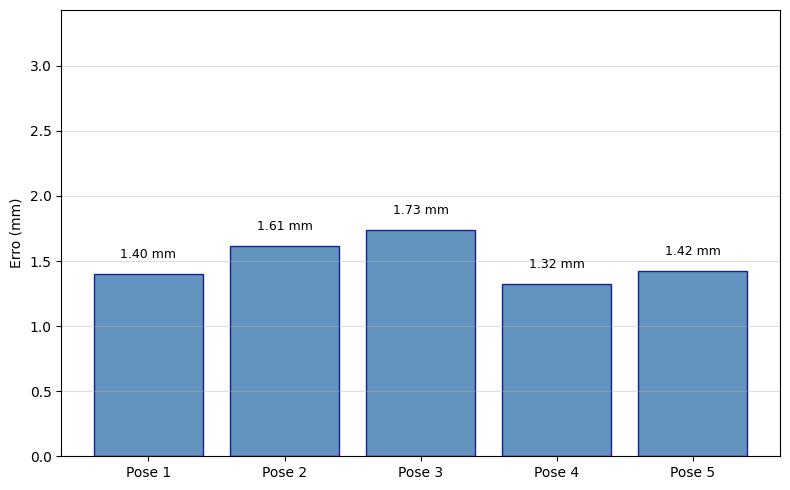

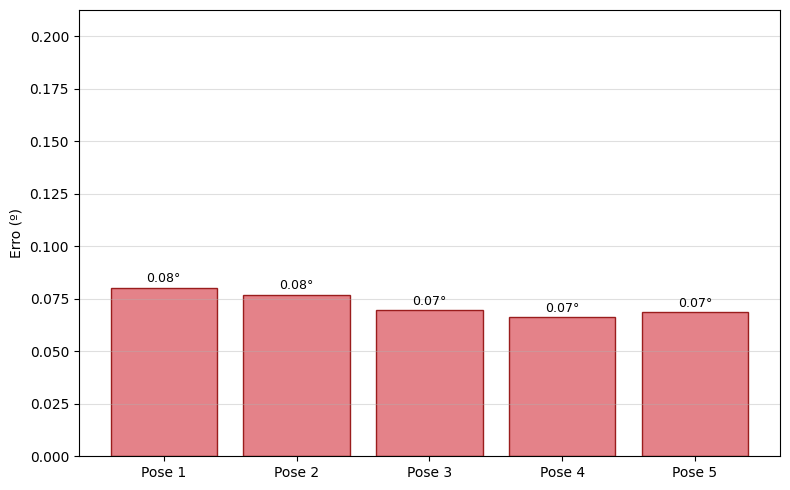

In [17]:
# ── Gráfico 1: Erro de Posição ────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5))

labels = [f'Pose {i+1}' for i in range(len(results))]
x = np.arange(len(results))

pos_errors = [r['pos_err'] for r in results]
bars1 = ax1.bar(x, pos_errors, color='steelblue', edgecolor='navy', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel('Erro (mm)')
#ax1.set_title('Erro de Posição do End-Effector')
ax1.set_ylim(0, max(pos_errors)*1.4 + 1)
for bar, val in zip(bars1, pos_errors):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f} mm', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.4)
plt.tight_layout()
#plt.savefig('fk_erro_posicao.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Gráfico 2: Erro de Orientação ────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 5))

ang_errors = [r['ang_err'] for r in results]
bars2 = ax2.bar(x, ang_errors, color='#e06c75', edgecolor='darkred', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel('Erro (º)')
#ax2.set_title('Erro de Orientação do End-Effector')
ax2.set_ylim(0, max(ang_errors)*1.4 + 0.1)
for bar, val in zip(bars2, ang_errors):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f'{val:.2f}°', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.4)
plt.tight_layout()
#plt.savefig('fk_erro_orientacao.png', dpi=150, bbox_inches='tight')
plt.show()